In [1]:
import os
import io
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import cudf

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import tensorflow as tf
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler

# Load Data

In [2]:
%%time
train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv').set_index("id")
test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv').set_index("id")
sample_submission = pd.read_csv("../input/tabular-playground-series-nov-2021/sample_submission.csv")

feature_cols = test.columns.tolist()

CPU times: user 19.7 s, sys: 1.25 s, total: 20.9 s
Wall time: 28.3 s


# Scale Data

In [3]:
sc = MinMaxScaler()
train[feature_cols] = sc.fit_transform(train[feature_cols])
test[feature_cols] = sc.transform(test[feature_cols])

# Plot Features

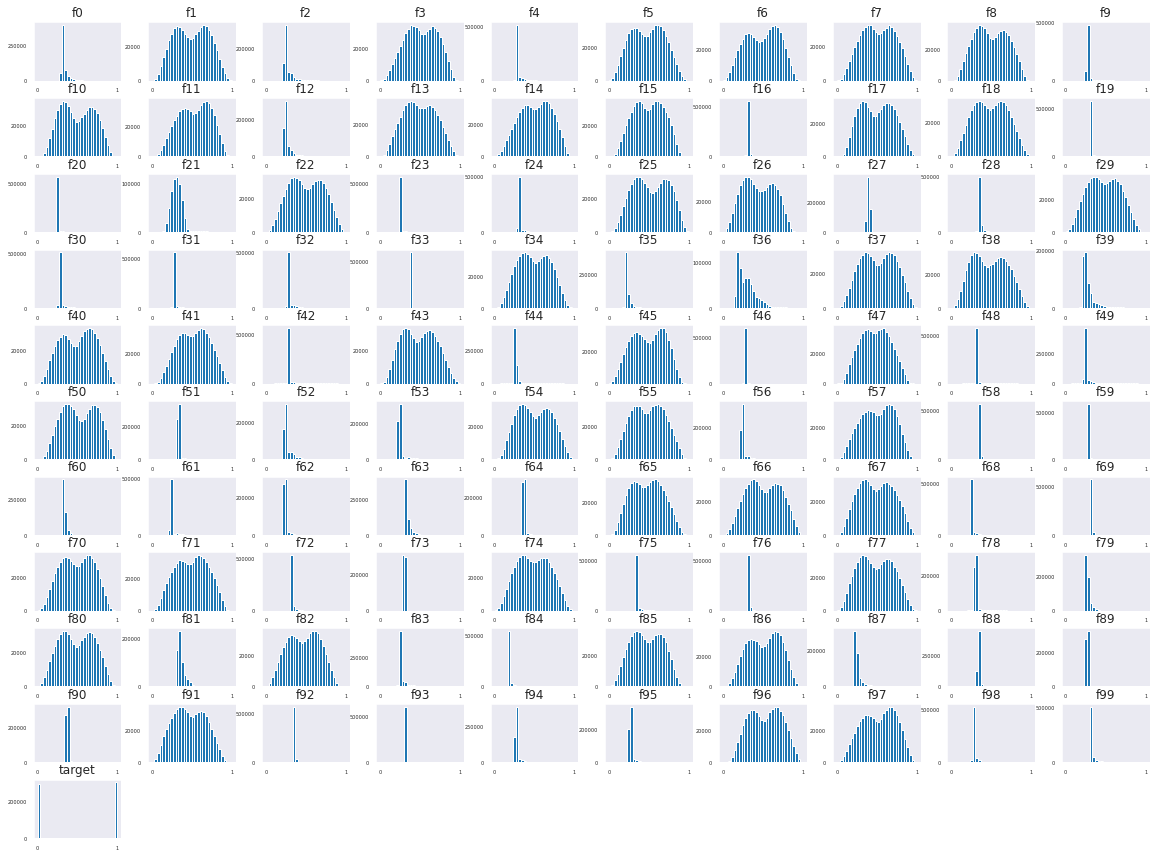

In [4]:
train.hist(figsize=(20,15), grid=False, ylabelsize=5, xlabelsize=5, bins=30)
plt.show()

In [5]:
dist1 = [ 'f1', 'f3', 'f5','f6','f7','f8', 'f10','f11', 'f13','f14', 'f15', 'f17','f18','f21','f22','f25','f26','f29','f34','f36','f37',\
 'f38','f40','f41','f43','f45', 'f46',  'f50','f54','f55','f57', 'f75','f76', 'f77','f80','f82','f85','f86','f91','f96','f97']

dist2 = []
for col in feature_cols:
    if col not in dist1:
        dist2.append(col)

# Categorize Data

In [6]:
%%time
bins = 128
n = 0
bins_list = []

bins_list.append(-np.inf)
for i in range(1,bins):
    n += 1./bins
    bins_list.append(n)
bins_list.append(np.inf)

labels = [i for i in range(bins)]
for col in dist1:
    train[col] = pd.cut(train[col], bins=bins_list, labels=labels)
    test[col] = pd.cut(test[col], bins=bins_list, labels=labels)
    
train.head()

CPU times: user 6.23 s, sys: 5.21 s, total: 11.4 s
Wall time: 11.5 s


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
id,,,,,,,,,,,,,,,,,,,,,
0,0.310367,82,0.248101,73,0.286635,39,80,60,56,0.268236,...,38,0.346948,0.312845,0.269025,0.271991,94,55,0.276378,0.344739,0
1,0.311828,49,0.241034,77,0.288154,104,39,13,97,0.270864,...,76,0.347080,0.322025,0.277665,0.381735,21,66,0.269139,0.320139,0
2,0.304777,46,0.260754,57,0.281835,71,102,87,51,0.272862,...,100,0.349499,0.315810,0.274427,0.258393,17,58,0.278985,0.334218,0
3,0.300770,25,0.329385,52,0.280095,44,62,98,96,0.279748,...,77,0.345867,0.313088,0.269815,0.267085,34,55,0.273264,0.322437,0
4,0.301630,84,0.251031,57,0.281083,54,87,21,77,0.270498,...,51,0.344950,0.320731,0.275193,0.266338,42,40,0.269685,0.325621,1


In [7]:
train[dist1] = train[dist1].astype('uint8')
test[dist1] = test[dist1].astype('uint8')

In [8]:
x1 = train[dist1].values
x2 = train[dist2].values
y  = train['target'].values

# Neural Network Model

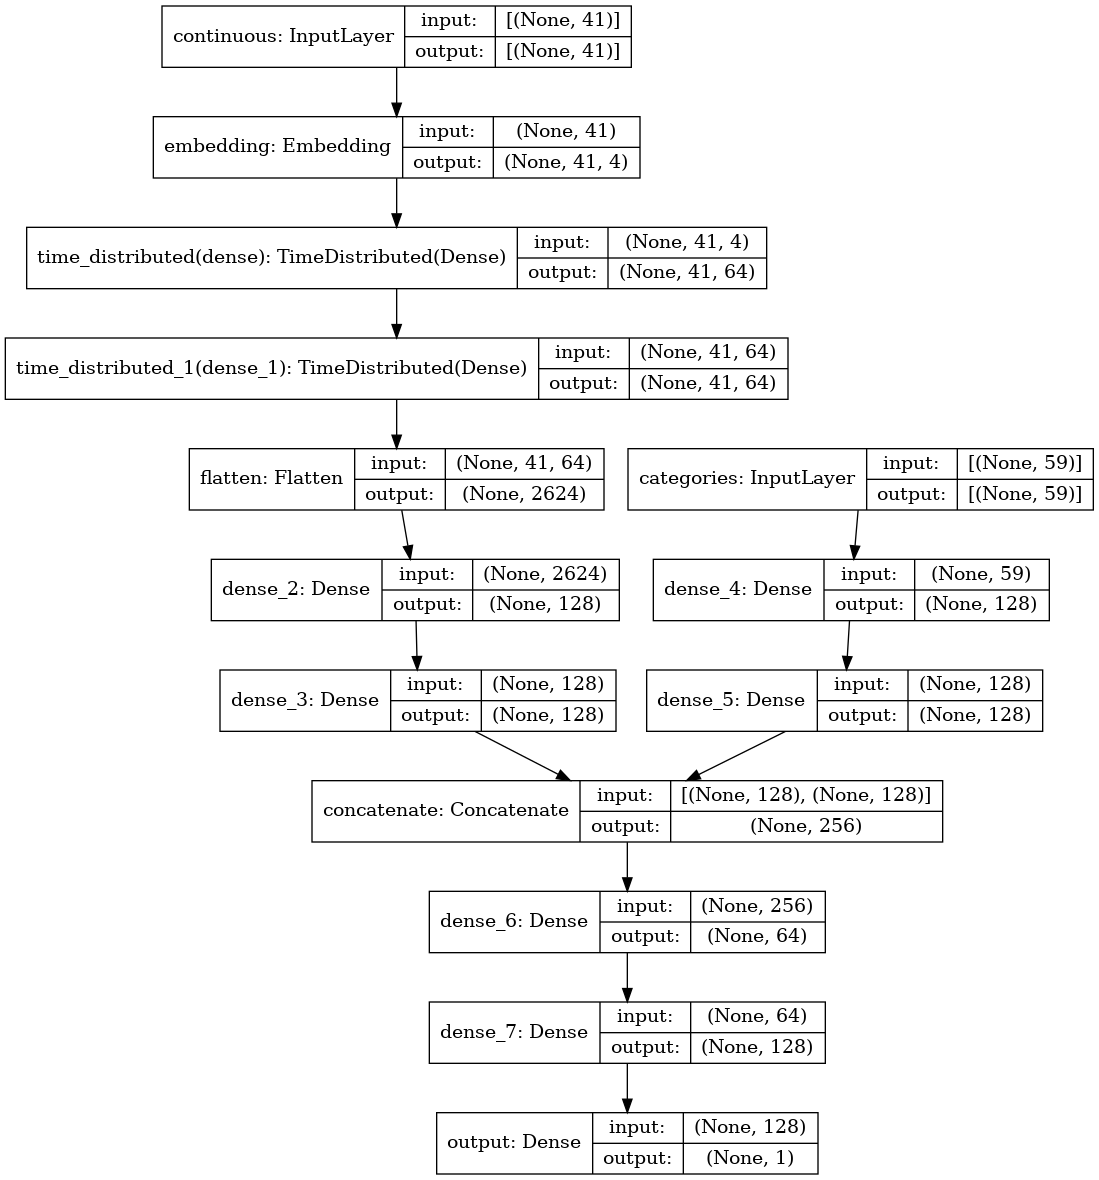

In [9]:
def get_model():
    AF = "relu"
    input_1 = layers.Input(shape=(x1.shape[-1]), name="continuous")
    x_1 = layers.Embedding(input_dim=bins, output_dim=4)(input_1)
    x_1 = layers.TimeDistributed(layers.Dense(64, activation=AF))(x_1)
    x_1 = layers.TimeDistributed(layers.Dense(64, activation=AF))(x_1)
    x_1 = layers.Flatten()(x_1)
    x_1 = layers.Dense(128, activation=AF)(x_1)
    x_1 = layers.Dense(128, activation=AF)(x_1)
    
    input_2 = layers.Input(shape=x2.shape[-1], name="categories")
    x_2 = layers.Dense(128, activation=AF)(input_2)
    x_2 = layers.Dense(128, activation=AF)(x_2)

    x = layers.Concatenate()([x_1,x_2])
    x = layers.Dense(64, activation=AF)(x)
    x = layers.Dense(128, activation=AF)(x)
    output = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = tf.keras.Model([input_1,input_2], output)
    return model


model = get_model()
model.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=["AUC"])
    
tf.keras.utils.plot_model(model, show_shapes=True)

In [10]:
cb_es = tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=4, mode="max", restore_best_weights=True, verbose=1)
cb_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=2, mode="max", min_lr=0.0001, verbose=1)

history = model.fit((x1,x2), 
                    y, 
                    epochs=40, 
                    validation_split=0.2, 
                    batch_size=512, 
                    validation_batch_size=512,
                    callbacks=[cb_es, cb_lr])

Epoch 1/40
938/938 [==============================] - 9s 7ms/step - loss: 0.6294 - auc: 0.6937 - val_loss: 0.5952 - val_auc: 0.7259
Epoch 2/40
938/938 [==============================] - 6s 6ms/step - loss: 0.5940 - auc: 0.7389 - val_loss: 0.5906 - val_auc: 0.7299
Epoch 3/40
938/938 [==============================] - 6s 7ms/step - loss: 0.5875 - auc: 0.7447 - val_loss: 0.5876 - val_auc: 0.7308
Epoch 4/40
938/938 [==============================] - 7s 7ms/step - loss: 0.5861 - auc: 0.7456 - val_loss: 0.5959 - val_auc: 0.7305
Epoch 5/40
938/938 [==============================] - 6s 7ms/step - loss: 0.5826 - auc: 0.7490 - val_loss: 0.5927 - val_auc: 0.7317
Epoch 6/40
938/938 [==============================] - 6s 7ms/step - loss: 0.5810 - auc: 0.7502 - val_loss: 0.5902 - val_auc: 0.7318
Epoch 7/40
938/938 [==============================] - 6s 6ms/step - loss: 0.5788 - auc: 0.7526 - val_loss: 0.5809 - val_auc: 0.7335
Epoch 8/40
938/938 [==============================] - 6s 7ms/step - loss: 0.

# Embeddings Projection

 You can uppload these two files (`vecs.tsv` and `meta.tsv`) on http://projector.tensorflow.org/ to visualize embedding layer

In [11]:
e = model.layers[1]
weights = e.get_weights()[0]
print(weights.shape)

words = [f"{i} ({np.round(bins_list[i],3)}-{np.round(bins_list[i+1],3)})" for i in labels]

vecs = io.open('vecs.tsv', 'w', encoding='utf-8')
meta = io.open('meta.tsv', 'w', encoding='utf-8')
for i in range(bins):
    vecs.write(words[i] + "\n")
    meta.write('\t'.join([str(x) for x in weights[i]]) + "\n")
vecs.close()
meta.close()

(128, 4)


# Predict

In [12]:
preds = model.predict((test[dist1].values, test[dist2].values))

# Plot Predictions

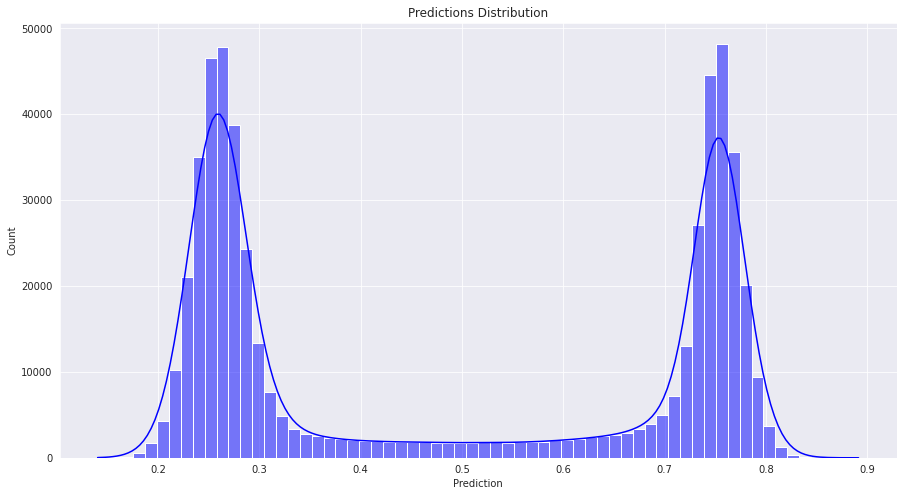

In [13]:
plt.figure(figsize=(15,8))
sns.histplot(x=preds.reshape(-1), kde=True, color="blue")
plt.title("Predictions Distribution")
plt.xlabel("Prediction")
plt.show()

# Submission

In [14]:
sample_submission['target'] = np.squeeze(preds)
sample_submission.to_csv("submission.csv", index=False)